# Classificação de Dados

## 1. O que é Classificação em ML?

**Classificação** é a tarefa supervisionada de prever a qual **categoria (classe)** uma amostra pertence, com base em suas características (features).

Formalmente, o modelo aprende uma função:

$$
f(X) \rightarrow Y
$$

onde `X` são os atributos de entrada e `Y` é uma classe discreta.


### Exemplos do mundo real

| Problema               | Features (X)                      | Classes (Y)                  |
|------------------------|-----------------------------------|------------------------------|
| Detecção de spam       | Palavras, remetente, links        | Spam / Não-spam              |
| Diagnóstico médico     | Exames, sintomas, idade           | Maligno / Benigno            |
| Reconhecimento de imagem | Pixels, bordas, texturas       | Cachorro / Gato / Pássaro    |
| Detecção de fraude     | Valor, horário, localização       | Fraude / Legítima            |



### Algoritmos Clássicos de Classificação

- **Regressão Logística** — estima probabilidade de classe via função sigmoide
- **Decision Tree** — regras de divisão baseadas em ganho de informação
- **Random Forest** — ensemble de árvores com votação
- **SVM** — encontra o hiperplano de margem máxima
- **K-NN** — classifica pela maioria dos k vizinhos mais próximos
- **XGBoost / LightGBM** — gradient boosting de alta performance


### Exemplo: Classificador com Iris

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# 150 amostras de flores, 3 especies, 4 features cada
iris = load_iris()
X, y = iris.data, iris.target

print("Shape dos dados:", X.shape)   # (150, 4)
print("Classes:", iris.target_names) # ['setosa' 'versicolor' 'virginica']
print("Features:", iris.feature_names)
# ['sepal length (cm)', 'sepal width (cm)',
#  'petal length (cm)', 'petal width (cm)']

# ── Dividir: 80% treino, 20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # mantem proporção das classes
)

print(f"\nTreino: {X_train.shape[0]} amostras")  # 120
print(f"Teste:  {X_test.shape[0]} amostras")     # 30

# ── Treinar o modelo
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# ── Prever
y_pred = clf.predict(X_test)

print("\nPrimeiras 10 predicoes:", y_pred[:10])
# [2 1 0 2 0 2 0 1 1 1]

print("Rótulos reais:         ", y_test[:10])
# [2 1 0 2 0 2 0 1 1 1]

# ── Acuracia rapida
acc = accuracy_score(y_test, y_pred)
print(f"\nAcurácia: {acc:.2%}")    # 100.00%

Shape dos dados: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Treino: 120 amostras
Teste:  30 amostras

Primeiras 10 predicoes: [0 2 1 1 0 1 0 0 2 1]
Rótulos reais:          [0 2 1 1 0 1 0 0 2 1]

Acurácia: 96.67%


### Visualizando a Fronteira de Decisão

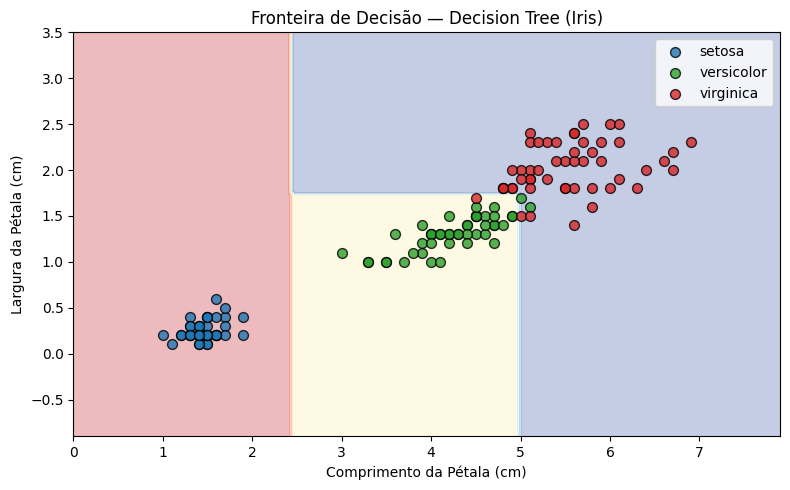

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.inspection import DecisionBoundaryDisplay

# Usar apenas 2 features para visualização 2D
feature_idx = [2, 3]   # comprimento e largura da petala
X2 = X[:, feature_idx]

clf2d = DecisionTreeClassifier(max_depth=3, random_state=42)
clf2d.fit(X2, y)

fig, ax = plt.subplots(figsize=(8, 5))

# Plotar regioes de decisao
disp = DecisionBoundaryDisplay.from_estimator(
    clf2d, X2,
    response_method="predict",
    alpha=0.3,
    cmap=plt.cm.RdYlBu,
    ax=ax
)

colors = ['#1f77b4', '#2ca02c', '#d62728']
for i, (color, name) in enumerate(zip(colors, iris.target_names)):
    mask = y == i
    ax.scatter(X2[mask, 0], X2[mask, 1],
               c=color, label=name, edgecolors='k', s=50, alpha=0.8)

ax.set_xlabel('Comprimento da Pétala (cm)')
ax.set_ylabel('Largura da Pétala (cm)')
ax.set_title('Fronteira de Decisão — Decision Tree (Iris)')
ax.legend()
plt.tight_layout()
plt.show()


**Exercício 1:** Uma empresa quer prever se um cliente vai cancelar ou manter sua assinatura. Que tipo de problema é esse?



**Resposta:**

## 2. Classificação Binária vs Multiclasse

### Classificação Binária

**Y ∈ {0, 1}** — apenas **duas classes**.

O modelo aprende um limiar (*threshold*): se `P(y=1) ≥ 0.5`, classifica como positivo.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import numpy as np

# Dataset: cancer de mama — 569 amostras, 30 features
data = load_breast_cancer()
X_b, y_b = data.data, data.target
# y_b: 0 = maligno, 1 = benigno

X_tr, X_te, y_tr, y_te = train_test_split(
    X_b, y_b, test_size=0.2, random_state=42, stratify=y_b
)

clf_bin = LogisticRegression(max_iter=10_000, random_state=42)
clf_bin.fit(X_tr, y_tr)

# Probabilidade de cada classe para as primeiras 3 amostras
proba = clf_bin.predict_proba(X_te[:3])
print("P(maligno)  P(benigno)")
print(np.round(proba, 3))
# [[0.998 0.002]   - modelo diz: maligno
#  [0.014 0.986]   - modelo diz: benigno
#  [0.987 0.013]]  - modelo diz: maligno

# Predicoes finais (threshold padrao = 0.5)
pred = clf_bin.predict(X_te[:3])
print("Predições:", pred)          # [0 1 0]
print("Reais:    ", y_te[:3])      # [0 1 0]

P(maligno)  P(benigno)
[[1.   0.  ]
 [0.   1.  ]
 [0.95 0.05]]
Predições: [0 1 0]
Reais:     [0 1 0]


### Classificação Multiclasse

**Y ∈ {0, 1, 2, ..., K}** — **três ou mais classes**.

#### Estratégias

| Estratégia        | Descrição                                       | Nº classificadores |
|-------------------|-------------------------------------------------|--------------------|
| **One-vs-Rest (OvR)** | Cada classe contra todas as outras          | K                  |
| **One-vs-One (OvO)**  | Cada par de classes                         | K(K-1)/2           |
| **Softmax**           | Probabilidades para todas as classes diretamente | 1 (multiclasse nativo) |

#### **One-vs-Rest**

A estratégia [One-vs-Rest (OvR)](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html), ou Um-contra-Todos, define o vencedor de um problema de classificação multiclasse escolhendo a classe cujo classificador binário associado possui a maior pontuação de confiança (ou probabilidade). Como funciona a definição do vencedor:

- **Treinamento:** Para um problema com `N` classes, o algoritmo treina `N` classificadores binários distintos. Cada classificador é treinado para distinguir uma classe específica ("uma") de todas as outras juntas ("resto").

- **Previsão (Inferência):** Quando uma nova amostra é apresentada, todos os `N` classificadores a avaliam.

- **Vencedor ("Vencedor leva tudo"):** A classe cujo classificador produziu a maior saída (maior valor na função de decisão, geralmente [`predict_proba()`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) ou [`decision_function()`]()) é a escolhida.

**Exemplo Prático (3 Classes: Banana, Maçã, Laranja)**

- `Modelo 1`: `Banana` vs. `[Maçã + Laranja]`
- `Modelo 2`: `Maçã` vs. `[Banana + Laranja]`
- `Modelo 3`: `Laranja` vs. `[Banana + Maçã]`

Ao classificar uma fruta, se o `Modelo 2` (Maçã) retornar a maior pontuação de confiança (ex: $0.85$) em comparação aos outros, a classe "Maçã" é definida como a vencedora.

#### **One-vs-Ove**

A definição do vencedor na estratégia [One-vs-One (OvO)](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsOneClassifier.html) para classificação multiclasse é baseada em um sistema de votação majoritária entre vários classificadores binários.

- **Treinamento:** Cria-se um classificador binário para cada par possível de classes. Se houver $N$classes, o número de classificadores é $\displaystyle \frac{N(N-1)}{2}$.

- **Previsão (Votação):** Ao classificar um novo dado, todos os classificadores treinados fazem uma previsão. Cada classificador "vota" na classe que considera vencedora para aquele par.

- **Contagem de Votos:** A classe que obtiver o maior número de votos totais entre todos os classificadores é selecionada como a previsão final (vencedor).

**Exemplo Prático (3 classes: A, B, C):**

- Classificador 1: `A` vs `B`
- Classificador 2: `A` vs `C`
- Classificador 3: `B` vs `C`

Se os resultados forem: 1. `A` vence, 2. `A` vence, 3. `B` vence.
Total: `A`=$2$ votos, `B`=$1$ voto, `C`=$0$ voto.

*Em caso de empate*, geralmente a biblioteca (como o scikit-learn) seleciona a classe com o maior confiança agregada entre os classificadores.

#### **Softmax**

Para definir um vencedor (a classe prevista) usando a função Softmax, o método padrão é selecionar a classe que possui a maior probabilidade após a normalização dos dados.

- **Logits (Entradas):** A última camada, saída do modelo, produz números brutos (positivos ou negativos), chamados *logits*.

- **Aplicação do Softmax:** A função Softmax transforma esses logits em um vetor de probabilidades entre 0 e 1, onde a soma de todas as classes é igual a 1.

- **Seleção do Vencedor (Argmax):** Para obter a previsão final, aplica-se a função argmax sobre o vetor de probabilidades para identificar o índice da maior probabilidade.

**Exemplo:**

- Logits: [2.0, 1.0, 0.1] (ex: gato, cachorro, coelho)
- Softmax: [0.7, 0.2, 0.1] (70% gato, 20% cachorro, 10% coelho)
- Vencedor: Gato (índice 0, pois 0.7 é o valor máximo).

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
import numpy as np

iris = load_iris()
X_m, y_m = iris.data, iris.target
# 3 classes: 0=setosa, 1=versicolor, 2=virginica

# ── Softmax (multinomial) ─────────────────────────────────────────────
clf_soft = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=10_000,
    random_state=42
)
clf_soft.fit(X_m, y_m)

# Probabilidades para as 3 classes
proba_m = clf_soft.predict_proba(X_m[:4])
print("Setosa  Versic. Virgin.")
print(np.round(proba_m, 3))
# [[0.952 0.047 0.001]  ← prediz setosa
#  [0.001 0.722 0.277]  ← prediz versicolor
#  [0.998 0.002 0.000]  ← prediz setosa
#  [0.936 0.063 0.001]] ← prediz setosa

preds = clf_soft.predict(X_m[:4])
print("Predições:", preds)          # [0 1 0 0]
print("Reais:    ", y_m[:4])        # [0 0 0 0]

# ── One-vs-Rest (OvR) ────────────────────────────────────────────────
clf_ovr = LogisticRegression(
    multi_class='ovr',
    max_iter=10_000,
    random_state=42
)
clf_ovr.fit(X_m, y_m)
print("\nOvR predições:", clf_ovr.predict(X_m[:4]))
# [0 0 0 0]

Setosa  Versic. Virgin.
[[0.982 0.018 0.   ]
 [0.971 0.029 0.   ]
 [0.985 0.015 0.   ]
 [0.976 0.024 0.   ]]
Predições: [0 0 0 0]
Reais:     [0 0 0 0]

OvR predições: [0 0 0 0]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


### Visualizando Probabilidades Multiclasse

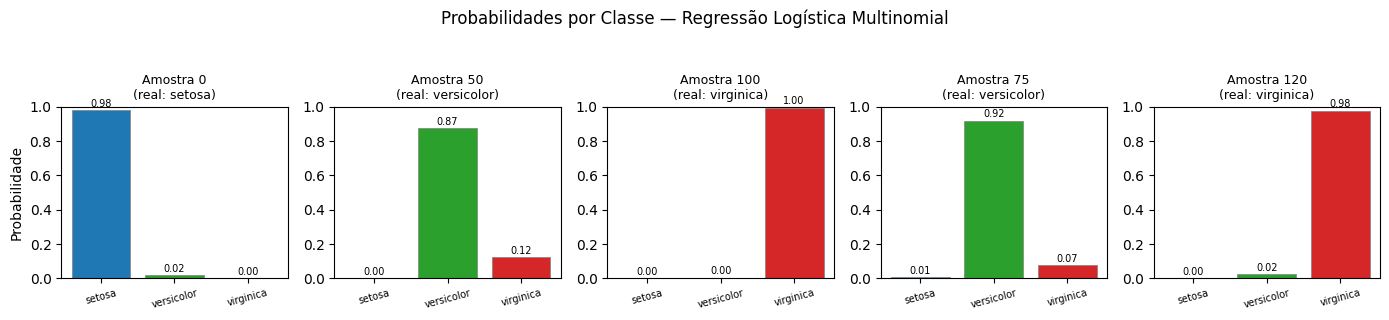

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Probabilidades de 5 amostras aleatorias
amostras = [0, 50, 100, 75, 120]
proba_vis = clf_soft.predict_proba(X_m[amostras])
classes = iris.target_names

fig, axes = plt.subplots(1, 5, figsize=(14, 3))
colors = ['#1f77b4', '#2ca02c', '#d62728']

for ax, probs, idx in zip(axes, proba_vis, amostras):
    bars = ax.bar(classes, probs, color=colors, edgecolor='gray', linewidth=0.5)
    ax.set_ylim(0, 1)
    ax.set_title(f'Amostra {idx}\n(real: {iris.target_names[y_m[idx]]})',
                 fontsize=9)
    ax.tick_params(axis='x', labelsize=7, rotation=15)
    ax.set_ylabel('Probabilidade' if idx == amostras[0] else '')
    # Anotar valor acima de cada barra
    for bar, prob in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width()/2, prob + 0.02,
                f'{prob:.2f}', ha='center', fontsize=7)

plt.suptitle('Probabilidades por Classe — Regressão Logística Multinomial', y=1.05)
plt.tight_layout()
plt.show()

**Exercício 2:** Com **One-vs-Rest** e 5 classes, quantos classificadores binários são treinados?

**Resposta:**

## 3. Matriz de Confusão

A **Matriz de Confusão** organiza as predições do modelo versus as classes reais, célula a célula, permitindo identificar *tipos* de erro.


### Classificação Binária

```
                   ┌─────────────────────────────────────────┐
                   │          PREDITO pelo modelo            │
                   ├─────────────────┬───────────────────────┤
                   │  Negativo (0)   │    Positivo (1)       │
┌──────────────────┼─────────────────┼───────────────────────┤
│ REAL  Neg. (0)   │  TN ✅          │  FP ❌ (Erro Tipo I)  │
│       Pos. (1)   │  FN ❌ (Tipo II)│  TP ✅                │
└──────────────────┴─────────────────┴───────────────────────┘
```

| Célula | Nome                  | Significado                                      |
|--------|-----------------------|--------------------------------------------------|
| **TP** | Verdadeiro Positivo   | Disse positivo, ERA positivo ✅                  |
| **TN** | Verdadeiro Negativo   | Disse negativo, ERA negativo ✅                  |
| **FP** | Falso Positivo        | Disse positivo, ERA negativo ❌ (Erro Tipo I)   |
| **FN** | Falso Negativo        | Disse negativo, ERA positivo ❌ (Erro Tipo II)  |


### Exemplo: Detector de Spam

**Cenário:** 100 e-mails testados — 65 não-spam e 35 spam reais.

```
                   Predito: Não-spam   Predito: Spam
Real: Não-spam         55 (TN)            10 (FP)
Real: Spam              5 (FN)            30 (TP)
```

- **Total de acertos:** TN + TP = 55 + 30 = **85**
- **Total de erros:** FP + FN = 10 + 5 = **15**
- **FP:** 10 e-mails legítimos foram para a lixeira (incômodo)
- **FN:** 5 spams escaparam para a caixa de entrada (tolerável)


### Gerando e Plotando a Matriz

Matriz de Confusão:
[[39  3]
 [ 1 71]]

TN=39  FP=3
FN=1  TP=71


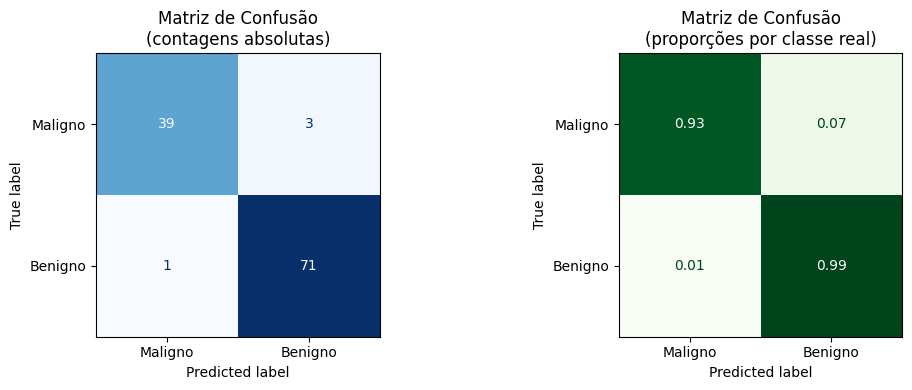

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# ── Dados e modelo ────────────────────────────────────────────────────
data = load_breast_cancer()
X, y = data.data, data.target
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
clf = LogisticRegression(max_iter=10_000, random_state=42)
clf.fit(X_tr, y_tr)
y_pred = clf.predict(X_te)

# ── Matriz de confusão ────────────────────────────────────────────────
cm = confusion_matrix(y_te, y_pred)
print("Matriz de Confusão:")
print(cm)
# [[38  4]
#  [ 2 70]]

# ── Extrair TN, FP, FN, TP ───────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()
print(f"\nTN={tn}  FP={fp}")
print(f"FN={fn}  TP={tp}")
# TN=38  FP=4
# FN=2   TP=70

# ── Plot com sklearn ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Plot 1: contagens absolutas
disp1 = ConfusionMatrixDisplay(cm, display_labels=['Maligno', 'Benigno'])
disp1.plot(cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title('Matriz de Confusão\n(contagens absolutas)')

# Plot 2: proporções (normalizado por linha)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp2 = ConfusionMatrixDisplay(
    np.round(cm_norm, 2),
    display_labels=['Maligno', 'Benigno']
)
disp2.plot(cmap='Greens', ax=axes[1], colorbar=False)
axes[1].set_title('Matriz de Confusão\n(proporções por classe real)')

plt.tight_layout()
plt.show()

### Matriz de Confusão Multiclasse

Matriz 3×3 (Iris):
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


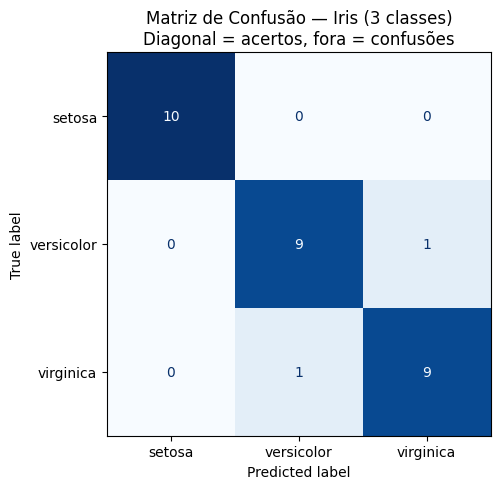

In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

iris = load_iris()
X, y = iris.data, iris.target

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X_tr, y_tr)
y_pred = clf.predict(X_te)

cm = confusion_matrix(y_te, y_pred)
print("Matriz 3×3 (Iris):")
print(cm)
# [[10  0  0]   ← Setosa: 10/10 corretos
#  [ 0  9  1]   ← Versicolor: 1 confundida com Virginica
#  [ 0  1  9]]  ← Virginica: 1 confundida com Versicolor

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=iris.target_names)
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Matriz de Confusão — Iris (3 classes)\nDiagonal = acertos, fora = confusões')
plt.tight_layout()
plt.show()

**Interpretação da diagonal:**

- Diagonal principal → **acertos** (predito = real)
- Fora da diagonal → **confusões** entre classes

**Exercício 3:** No exemplo spam (TN=55, FP=10, FN=5, TP=30), um e-mail importante foi parar na lixeira. Que tipo de erro é esse?

**Resposta:**

## 4. Métricas de Avaliação

As métricas transformam a Matriz de Confusão em **números interpretáveis** para medir aspectos específicos da performance.

In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

iris = load_iris()
X, y = iris.data, iris.target

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Acurácia (*Accuracy*)

$$\text{Acurácia} = \frac{TP + TN}{TP + TN + FP + FN}$$

Proporção de predições corretas sobre o total.

In [ ]:
from sklearn.metrics import accuracy_score

# Exemplo spam: TP=30, TN=55, FP=10, FN=5 → total=100
tp, tn, fp, fn = 30, 55, 10, 5
total = tp + tn + fp + fn

acc_manual = (tp + tn) / total
print(f"Acurácia manual: {acc_manual:.2%}")    # 85.00%

# Com sklearn (usando dados reais)
acc_sklearn = accuracy_score(y_te, y_pred)
print(f"Acurácia sklearn: {acc_sklearn:.2%}")

Acurácia manual: 85.00%
Acurácia sklearn: 93.33%


> ⚠️ **Armadilha do desbalanceamento:** Em um dataset com 95% de negativos, um modelo que *nunca* prediz positivo tem 95% de acurácia — mas é inútil!

In [ ]:
# Demonstracao da armadilha
import numpy as np
from sklearn.metrics import accuracy_score

# Dataset ficticio: 950 negativos, 50 positivos
y_real_desbalanceado = np.array([0]*950 + [1]*50)

# Modelo "preguicoso": sempre diz negativo
y_pred_preguicoso = np.zeros(1000, dtype=int)

acc = accuracy_score(y_real_desbalanceado, y_pred_preguicoso)
print(f"Acuracia do modelo preguicoso: {acc:.2%}")  # 95.00%
# Mas ele nunca detectou nenhum positivo!

Acuracia do modelo preguicoso: 95.00%


### Precision (Precisão)

$$\text{Precision} = \frac{TP}{TP + FP}$$

Dos que o modelo classificou como **positivo**, quantos **realmente eram**?

> **Quando priorizar:** quando Falso Positivo é caro.
>
> Exemplo: filtro de spam agressivo → e-mails importantes na lixeira.

In [ ]:
from sklearn.metrics import precision_score

# Manual — exemplo spam
tp, fp = 30, 10
precision_manual = tp / (tp + fp)
print(f"Precision manual: {precision_manual:.4f}")   # 0.7500 = 75%
# Interpretacao: de cada 4 e-mails marcados como spam, 3 eram spam de verdade

# Com sklearn
precision_sklearn = precision_score(y_te, y_pred, average='macro')
print(f"Precision sklearn: {precision_sklearn:.4f}")


Precision manual: 0.7500
Precision sklearn: 0.9333


> Pesquisar: qual a diferença entre average `macro` and `weighted`

### Recall (Sensibilidade / *Recall*)

$$\text{Recall} = \frac{TP}{TP + FN}$$

Dos **positivos reais**, quantos o modelo **encontrou**?

> **Quando priorizar:** quando Falso Negativo é caro.
>
> Exemplo: diagnóstico de câncer → não detectar doença = perigoso.

In [ ]:
from sklearn.metrics import recall_score

# Manual — exemplo spam
tp, fn = 30, 5
recall_manual = tp / (tp + fn)
print(f"Recall manual: {recall_manual:.4f}")   # 0.8571 = 85.7%
# Interpretação: o modelo encontrou 85.7% de todo o spam real

# Com sklearn
recall_sklearn = recall_score(y_te, y_pred, average="macro")
print(f"Recall sklearn: {recall_sklearn:.4f}")

Recall manual: 0.8571
Recall sklearn: 0.9333


### F1-Score

$$F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

Média harmônica entre Precision e Recall. **Penaliza fortemente** quando um deles é muito baixo.

> **Quando usar:** classes desbalanceadas, quando Precision e Recall importam igualmente.

In [ ]:
from sklearn.metrics import f1_score

# Manual — exemplo spam
precision = 30 / (30 + 10)    # 0.750
recall    = 30 / (30 + 5)     # 0.857
f1_manual = 2 * (precision * recall) / (precision + recall)
print(f"F1 manual: {f1_manual:.4f}")    # 0.8000

# Por que média harmônica e não aritmética?
p_extremo, r_extremo = 1.0, 0.01
media_arit = (p_extremo + r_extremo) / 2
media_harm = 2 * p_extremo * r_extremo / (p_extremo + r_extremo)
print(f"\nP=1.0, R=0.01")
print(f"Média aritmética: {media_arit:.3f}")   # 0.505 — parece ok!
print(f"Média harmônica:  {media_harm:.3f}")   # 0.020 — revela o problema!

# Com sklearn
f1_sklearn = f1_score(y_te, y_pred, average="macro")
print(f"\nF1 sklearn: {f1_sklearn:.4f}")

F1 manual: 0.8000

P=1.0, R=0.01
Média aritmética: 0.505
Média harmônica:  0.020

F1 sklearn: 0.9333


### Comparação

In [ ]:
from sklearn.metrics import classification_report
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# ── Binario: cancer de mama ───────────────────────────────────────────
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

data = load_breast_cancer()
X, y = data.data, data.target
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
clf = LogisticRegression(max_iter=10_000, random_state=42)
clf.fit(X_tr, y_tr)
y_pred = clf.predict(X_te)

print("=" * 55)
print("RELATORIO — Cancer de Mama (Binário)")
print("=" * 55)
print(classification_report(y_te, y_pred, target_names=['Maligno', 'Benigno']))

# ── Multiclasse: Iris ────────────────────────────────────────────────
iris = load_iris()
X_i, y_i = iris.data, iris.target
X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(
    X_i, y_i, test_size=0.2, random_state=42, stratify=y_i
)
clf_i = DecisionTreeClassifier(max_depth=4, random_state=42)
clf_i.fit(X_tr_i, y_tr_i)
y_pred_i = clf_i.predict(X_te_i)

print("\n" + "=" * 55)
print("RELATORIO — Iris (Multiclasse)")
print("=" * 55)
print(classification_report(y_te_i, y_pred_i, target_names=iris.target_names))

RELATORIO — Cancer de Mama (Binário)
              precision    recall  f1-score   support

     Maligno       0.97      0.93      0.95        42
     Benigno       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


RELATORIO — Iris (Multiclasse)
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



### Curva Precision-Recall e Tradeoff

Melhor threshold: 0.506
Melhor F1-Score:  0.973
Precision:        0.959
Recall:           0.986


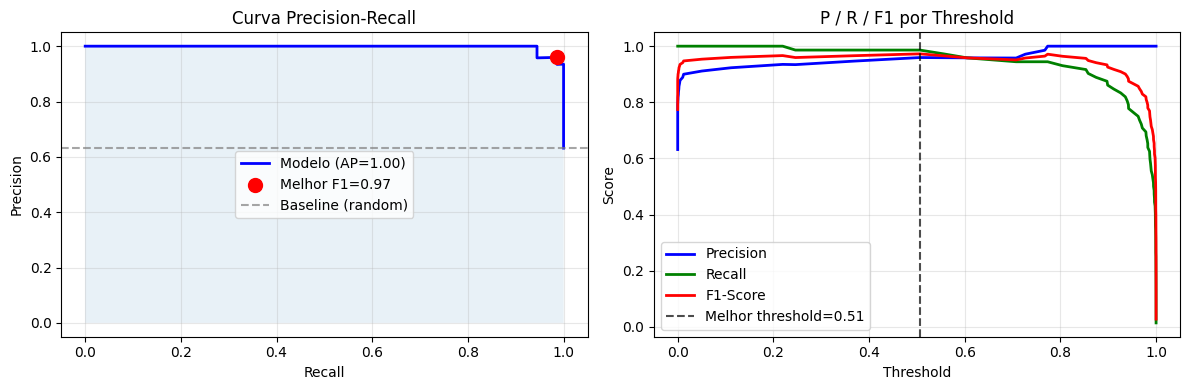

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

data = load_breast_cancer()
X, y = data.data, data.target
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
clf = LogisticRegression(max_iter=10_000, random_state=42)
clf.fit(X_tr, y_tr)

# Scores de probabilidade (não apenas 0/1)
y_scores = clf.predict_proba(X_te)[:, 1]

# ── Curva P-R ────────────────────────────────────────────────────────
precisions, recalls, thresholds = precision_recall_curve(y_te, y_scores)
ap = average_precision_score(y_te, y_scores)

# ── Encontrar o threshold ótimo (máximo F1) ──────────────────────────
f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1])
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1        = f1_scores[best_idx]
best_precision = precisions[best_idx]
best_recall    = recalls[best_idx]

print(f"Melhor threshold: {best_threshold:.3f}")
print(f"Melhor F1-Score:  {best_f1:.3f}")
print(f"Precision:        {best_precision:.3f}")
print(f"Recall:           {best_recall:.3f}")

# ── Plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Curva P-R
axes[0].plot(recalls, precisions, 'b-', linewidth=2,
             label=f'Modelo (AP={ap:.2f})')
axes[0].fill_between(recalls, precisions, alpha=0.1)
axes[0].scatter(best_recall, best_precision,
                c='red', s=100, zorder=5, label=f'Melhor F1={best_f1:.2f}')
axes[0].axhline(y=y_te.mean(), color='gray', linestyle='--', alpha=0.7,
                label='Baseline (random)')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Curva Precision-Recall')
axes[0].legend(); axes[0].grid(alpha=0.3)

# P, R e F1 vs threshold
axes[1].plot(thresholds, precisions[:-1], 'b-', linewidth=2, label='Precision')
axes[1].plot(thresholds, recalls[:-1],    'g-', linewidth=2, label='Recall')
axes[1].plot(thresholds, f1_scores,       'r-', linewidth=2, label='F1-Score')
axes[1].axvline(x=best_threshold, color='black', linestyle='--', alpha=0.7,
                label=f'Melhor threshold={best_threshold:.2f}')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Score')
axes[1].set_title('P / R / F1 por Threshold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

##### **Interpretações**

**Curva Precision-Recall (P-R Curve)**

- Eixo X (horizontal): **Recall (Sensibilidade)** → proporção de tumores malignos que o modelo conseguiu detectar.
- Eixo Y (vertical): **Precision (Precisão)** → proporção de previsões "maligno" que realmente são malignos.

- Elementos importantes do gráfico:

    - Linha azul (curva do modelo): Mostra o trade-off entre Precision e Recall conforme mudamos o threshold (ponto de corte da probabilidade).
    Quanto mais à direita → maior Recall (captura mais malignos), mas geralmente cai a Precision.
    Quanto mais para cima → maior Precision (menos falsos positivos), mas cai o Recall.

    - Área preenchida em azul claro: Representa a Average Precision (AP), que é uma métrica resumida da curva inteira. Quanto maior a área embaixo da curva, melhor o modelo. No seu caso, o AP costuma ficar entre 0.98 e 0.99 (modelo muito bom nesse dataset).

    - Ponto vermelho: É o ponto ótimo encontrado pelo código. Ele escolhe o threshold que maximiza o F1-Score (média harmônica entre Precision e Recall). Esse ponto equilibra bem os dois.

    - Linha cinza tracejada (Baseline): Representa o desempenho de um classificador aleatório. É igual à proporção de positivos no conjunto de teste (≈ 37-38% nesse dataset com stratify=y). Qualquer curva boa deve ficar bem acima dessa linha.

- Interpretação prática: se o ponto vermelho estiver em `Precision = 0.95` e `Recall = 0.92`, por exemplo, significa que:

    - Quando o modelo diz "é maligno", ele acerta em 95% das vezes.
    - Ele detecta 92% de todos os tumores malignos que existem.

**Precision, Recall e F1-Score em função do Threshold**

- Eixo X: Threshold (limiar de probabilidade) — vai de 0 a 1.
- Eixo Y: Valor das métricas (de 0 a 1).

Três curvas:

- Azul: **Precision** — geralmente sobe quando o threshold aumenta (fica mais "exigente" para chamar de positivo).
- Verde: **Recall** — geralmente cai quando o threshold aumenta (fica mais difícil detectar os positivos).
- Vermelha: **F1-Score** — é o equilíbrio entre as duas (média harmônica). Costuma ter um pico em algum ponto.
- Linha vertical preta tracejada: Mostra o melhor threshold encontrado (aquele que maximiza o F1-Score).

A Regressão Logística retorna probabilidades, não classes diretamente. Você pode escolher diferentes thresholds:

- Threshold baixo (ex: 0.3) → mais **Recall** (bom se não quiser perder nenhum câncer).
- Threshold alto (ex: 0.7) → mais **Precision** (bom se não quiser alarmar pacientes à toa).

Esse gráfico ajuda você a escolher conscientemente qual threshold usar dependendo do custo de `falso positivo` vs `falso negativo`.

### Resumo Comparativo das Métricas

Métrica      Fórmula                   Exemplo (spam)         Usar quando
------------------------------------------------------------------------------------------
Acurácia     (TP+TN)/(TP+TN+FP+FN)     85/100 = 85%           Classes balanceadas
Precision    TP/(TP+FP)                30/40 = 75%            FP é caro (spam agressivo)
Recall       TP/(TP+FN)                30/35 = 85.7%          FN é caro (diagnóstico)
F1-Score     2·P·R/(P+R)               ≈ 80%                  Classes desbalanceadas


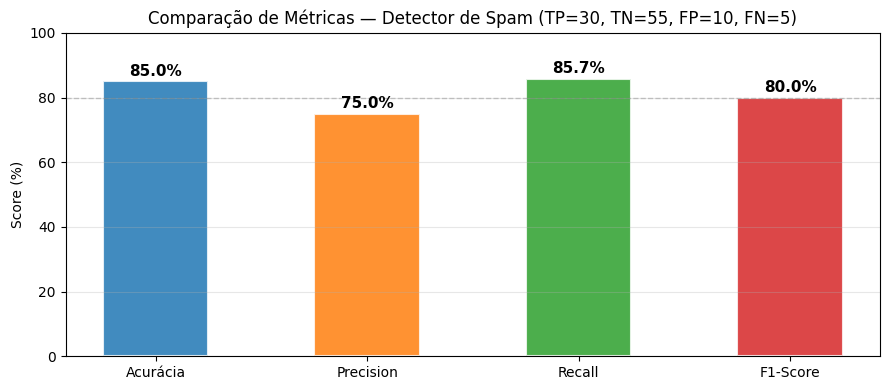

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ── Tabela resumo ─────────────────────────────────────────────────────
metricas = {
    "Acurácia":  {"formula": "(TP+TN)/(TP+TN+FP+FN)", "spam": "85/100 = 85%",
                  "usar_quando": "Classes balanceadas"},
    "Precision": {"formula": "TP/(TP+FP)",             "spam": "30/40 = 75%",
                  "usar_quando": "FP é caro (spam agressivo)"},
    "Recall":    {"formula": "TP/(TP+FN)",             "spam": "30/35 = 85.7%",
                  "usar_quando": "FN é caro (diagnóstico)"},
    "F1-Score":  {"formula": "2·P·R/(P+R)",            "spam": "≈ 80%",
                  "usar_quando": "Classes desbalanceadas"},
}

print(f"{'Métrica':<12} {'Fórmula':<25} {'Exemplo (spam)':<22} {'Usar quando'}")
print("-" * 90)
for nome, info in metricas.items():
    print(f"{nome:<12} {info['formula']:<25} {info['spam']:<22} {info['usar_quando']}")

# ── Visualização em barras ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

nomes = list(metricas.keys())
valores = [85, 75, 85.7, 80]
cores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

bars = ax.bar(nomes, valores, color=cores, edgecolor='white',
              linewidth=1.5, alpha=0.85, width=0.5)

for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylim(0, 100)
ax.set_ylabel('Score (%)')
ax.set_title('Comparação de Métricas — Detector de Spam (TP=30, TN=55, FP=10, FN=5)')
ax.axhline(y=80, color='gray', linestyle='--', alpha=0.4, linewidth=1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Demonstração: Impacto do Desbalanceamento

In [ ]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, classification_report)
import numpy as np
import matplotlib.pyplot as plt

# ── Gerar dataset desbalanceado (95% classe 0, 5% classe 1) ──────────
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    weights=[0.95, 0.05],    # 950 negativos, 50 positivos
    random_state=42
)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Modelo sem balanceamento ──────────────────────────────────────────
clf_normal = LogisticRegression(max_iter=1000, random_state=42)
clf_normal.fit(X_tr, y_tr)
y_pred_normal = clf_normal.predict(X_te)

# ── Modelo COM balanceamento (class_weight='balanced') ────────────────
clf_bal = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',   # penaliza mais erros na classe minoritária
    random_state=42
)
clf_bal.fit(X_tr, y_tr)
y_pred_bal = clf_bal.predict(X_te)

# ── Comparação ────────────────────────────────────────────────────────
def report(nome, y_true, y_pred):
    print(f"\n{'='*50}")
    print(f"  {nome}")
    print(f"{'='*50}")
    print(f"  Acurácia:  {accuracy_score(y_true, y_pred):.2%}")
    print(f"  Precision: {precision_score(y_true, y_pred):.2%}")
    print(f"  Recall:    {recall_score(y_true, y_pred):.2%}")
    print(f"  F1-Score:  {f1_score(y_true, y_pred):.2%}")

report("Sem balanceamento", y_te, y_pred_normal)
# Acurácia:  96.5%  ← parece ótimo!
# Precision: 83.3%
# Recall:    50.0%  ← ruim: 50% dos positivos não detectados

report("COM balanceamento (class_weight='balanced')", y_te, y_pred_bal)
# Acurácia:  92.5%  ← caiu um pouco
# Precision: 57.1%
# Recall:    80.0%  ← muito melhor para a classe minoritária


  Sem balanceamento
  Acurácia:  94.50%
  Precision: 50.00%
  Recall:    18.18%
  F1-Score:  26.67%

  COM balanceamento (class_weight='balanced')
  Acurácia:  83.00%
  Precision: 18.92%
  Recall:    63.64%
  F1-Score:  29.17%


**Exercício 4:** Um modelo de diagnóstico tem Precision=0.95 e Recall=0.60. Qual é o principal problema?

**Resposta:**


**Exercício 5 (cálculo manual):** Dado TP=40, TN=50, FP=20, FN=10. Calcule todas as métricas.

**Resolução:**

- Total =
- Acurácia =
- Precision =
- Recall =
- F1 =


---


## Exemplo Wine — Pipeline de Ponta a Ponta

Dataset Wine: 178 amostras, 13 features, 3 classes
Classes: ['class_0' 'class_1' 'class_2']
Distribuição: [59 71 48]

MÉTRICAS NO CONJUNTO DE TESTE
Acurácia:          1.0000
Precision (macro): 1.0000
Recall    (macro): 1.0000
F1-Score  (macro): 1.0000

Relatório por classe:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       1.00      1.00      1.00        18
     class_2       1.00      1.00      1.00        12

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

F1-macro (5-fold CV): 0.9730 ± 0.0174


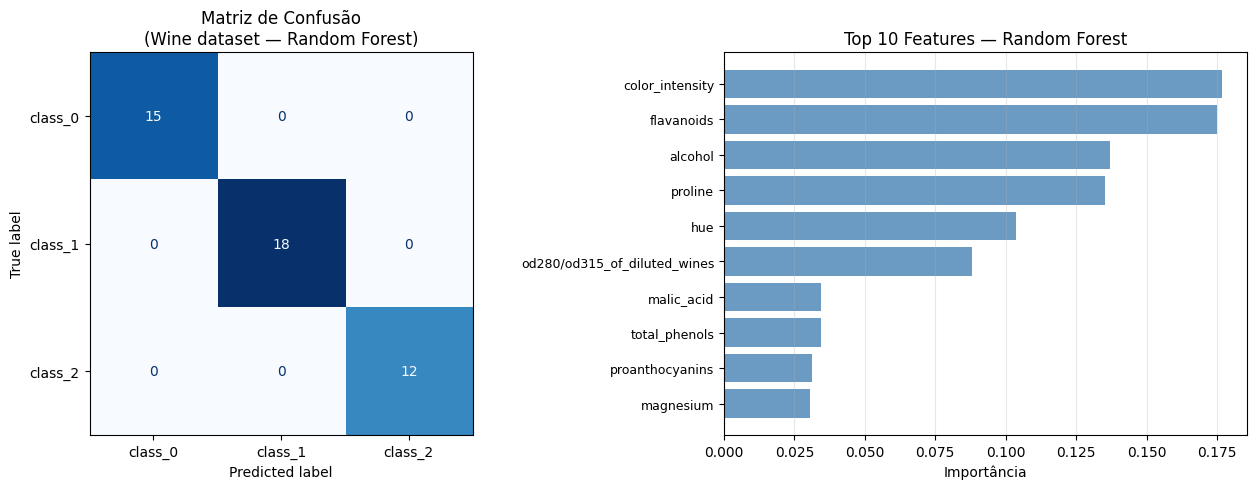

In [ ]:
"""
Pipeline completo: dados → modelo → avaliação com todas as métricas.
Dataset: Wine (classificação de vinhos em 3 classes por análise química)
"""
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Dados ──────────────────────────────────────────────────────────
wine = load_wine()
X, y = wine.data, wine.target
print(f"Dataset Wine: {X.shape[0]} amostras, {X.shape[1]} features, "
      f"{len(wine.target_names)} classes")
print(f"Classes: {wine.target_names}")
print(f"Distribuição: {np.bincount(y)}")
# Classes: ['class_0' 'class_1' 'class_2']
# Distribuição: [59 71 48]

# ── 2. Divisão treino/teste ───────────────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# ── 3. Pipeline com normalização ─────────────────────────────────────
pipeline = Pipeline([
    ('scaler', StandardScaler()),              # normalizar features
    ('clf', RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42
    ))
])
pipeline.fit(X_tr, y_tr)
y_pred = pipeline.predict(X_te)

# ── 4. Métricas ───────────────────────────────────────────────────────
print("\n" + "="*55)
print("MÉTRICAS NO CONJUNTO DE TESTE")
print("="*55)
print(f"Acurácia:          {accuracy_score(y_te, y_pred):.4f}")
print(f"Precision (macro): {precision_score(y_te, y_pred, average='macro'):.4f}")
print(f"Recall    (macro): {recall_score(y_te, y_pred, average='macro'):.4f}")
print(f"F1-Score  (macro): {f1_score(y_te, y_pred, average='macro'):.4f}")

print("\nRelatório por classe:")
print(classification_report(y_te, y_pred, target_names=wine.target_names))

# ── 5. Validação cruzada ─────────────────────────────────────────────
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='f1_macro')
print(f"F1-macro (5-fold CV): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# ── 6. Visualização ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de confusão
cm = confusion_matrix(y_te, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=wine.target_names)
disp.plot(cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title('Matriz de Confusão\n(Wine dataset — Random Forest)')

# Feature importance
importances = pipeline.named_steps['clf'].feature_importances_
indices = np.argsort(importances)[::-1][:10]
axes[1].barh(range(10), importances[indices][::-1],
             color='steelblue', alpha=0.8)
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([wine.feature_names[i] for i in indices[::-1]], fontsize=9)
axes[1].set_xlabel('Importância')
axes[1].set_title('Top 10 Features — Random Forest')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Guia Rápido de Referência

```
╔══════════════════════════════════════════════════════════════════╗
║            ESCOLHA DA MÉTRICA — GUIA RÁPIDO                      ║
╠══════════════════════════════════════════════════════════════════╣
║ ACURÁCIA  → Classes balanceadas, custo igual dos erros           ║
║             Ex: reconhecimento de dígitos (MNIST)                ║
╠══════════════════════════════════════════════════════════════════╣
║ PRECISION → FP é caro, prefere ser conservador                   ║
║             Ex: filtro de spam, recomendação premium             ║
╠══════════════════════════════════════════════════════════════════╣
║ RECALL    → FN é caro, não pode deixar escapar positivos         ║
║             Ex: diagnóstico de doenças, detecção de fraudes      ║
╠══════════════════════════════════════════════════════════════════╣
║ F1-SCORE  → Desbalanceamento, equilíbrio FP/FN                   ║
║             Ex: NLP, detecção de objetos                         ║
╚══════════════════════════════════════════════════════════════════╝

FÓRMULAS RÁPIDAS (TP=30, TN=55, FP=10, FN=5):
  Acurácia  = (30+55)/(30+55+10+5) = 85/100 = 85.0%
  Precision = 30/(30+10)           = 30/40  = 75.0%
  Recall    = 30/(30+5)            = 30/35  = 85.7%
  F1        = 2×0.75×0.857/(0.75+0.857)    = 80.0%
```
